# SquatchScout — a walk through the API

[SquatchScout](https://github.com/fasisandhu/squatchscout) turns "find me dentists in
Austin" into a **ranked, explained** list of acquisition targets. It discovers businesses
from OpenStreetMap, crawls their own sites politely, verifies the contacts it finds, and
scores each one across five factors so a searcher knows who to call first.

This notebook drives the live HTTP API the way any client would: start a search, consume
the server-sent event stream, then do the analysis in pandas. Every number below is
computed from a real run, not a fixture.

- Repo: <https://github.com/fasisandhu/squatchscout>
- Scoring model and data ethics: see the repo README
- The same search exported to CSV lives in [`../data/`](../data/)

In [1]:
import json
import os
import time

import httpx
import pandas as pd

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

# Point this at the deployed API to run the notebook against production.
API_BASE = os.getenv("API_BASE", "http://localhost:8000").rstrip("/")

# Re-running the whole notebook against a fresh search costs an Overpass query and a few
# dozen polite crawls, so set SEARCH_ID to reuse one you already have.
SEARCH_ID = os.getenv("SEARCH_ID") or None

client = httpx.Client(base_url=API_BASE, timeout=30)
health = client.get("/healthz").json()
print(json.dumps(health, indent=2))
assert health["status"] == "ok", "API is not healthy; start it or set API_BASE"


{
  "status": "ok",
  "db": "ok",
  "llm_enabled": true,
  "version": "dev"
}


## 1. Start a search and watch it stream

The API answers `POST /api/searches` immediately with an id and does the work in the
background. `GET /api/searches/{id}/stream` is a server-sent event stream with five event
types: `status`, `lead`, `lead_updated`, `done` and `error`.

`lead` arrives as soon as a business is discovered, scored and persisted, and carries the
whole lead under `id`. `lead_updated` arrives later, when the language model has finished
reading that business's website and the score has been recomputed; it is a **partial
patch** keyed on `lead_id`, not a whole lead, so a client merges it into the row it
already has. That split is the point of the streaming design: the table is usable in
seconds and keeps improving while you read it.

In [2]:
def run_search(industry="dentist", location="Austin, TX", limit=60, preset="balanced"):
    """Create a search and drain its SSE stream, returning (search_id, leads, event_log)."""
    sid = client.post(
        "/api/searches",
        json={
            "industry_key": industry,
            "location": location,
            "limit": limit,
            "weight_preset": preset,
        },
    ).json()["id"]
    print(f"search {sid}  ({industry} / {location} / {limit})\n")

    leads: dict[str, dict] = {}
    counts: dict[str, int] = {}
    started = time.monotonic()
    with client.stream("GET", f"/api/searches/{sid}/stream", timeout=600) as r:
        event = None
        for line in r.iter_lines():
            if line.startswith("event:"):
                event = line.split(":", 1)[1].strip()
            elif line.startswith("data:"):
                payload = json.loads(line.split(":", 1)[1].strip())
                counts[event] = counts.get(event, 0) + 1
                if event == "lead":
                    leads[payload["id"]] = payload
                elif event == "lead_updated":
                    # A delta, not a whole lead: merge it the way the web reducer does.
                    patch = {k: v for k, v in payload.items() if k != "lead_id"}
                    leads.setdefault(payload["lead_id"], {}).update(patch)
                elif event == "status":
                    print(f"  {time.monotonic() - started:5.1f}s  {payload.get('message', payload)}")
                elif event == "done":
                    print(f"  {time.monotonic() - started:5.1f}s  done: {payload}")
                    break
                elif event == "error":
                    raise RuntimeError(payload)
    print(f"\nevents: {counts}")
    return sid, list(leads.values()), counts


if SEARCH_ID:
    print(f"reusing search {SEARCH_ID}")
    leads = client.get(f"/api/searches/{SEARCH_ID}/leads").json()
else:
    SEARCH_ID, leads, _ = run_search()

print(f"{len(leads)} leads")


search b29bb1e3c9444bc49a3338e6a14caa4a  (dentist / Austin, TX / 60)

    0.0s  Locating Austin, TX…


    1.4s  Finding dentists in Austin…


    6.0s  Checking 54 businesses…


   47.6s  Refining 12 leads with AI…


  137.5s  done: {'lead_count': 54, 'llm_pending': 1}

events: {'status': 4, 'lead': 54, 'lead_updated': 11, 'done': 1}
54 leads


## 2. Wait for the AI pass to drain

Extraction runs on a free Groq tier with a per-minute token budget, so refinement
continues after `done`. `llm_pending` on the search object counts the jobs still queued.
A real client polls; so does this notebook.

In [3]:
for attempt in range(30):
    search = client.get(f"/api/searches/{SEARCH_ID}").json()
    if search["llm_pending"] == 0:
        break
    print(f"  {search['llm_pending']} leads still being refined...")
    time.sleep(10)

leads = client.get(f"/api/searches/{SEARCH_ID}/leads").json()
print(json.dumps({k: search[k] for k in ("status", "geocoded_name", "lead_count", "llm_pending")}, indent=2))


  1 leads still being refined...


  1 leads still being refined...


  1 leads still being refined...


  1 leads still being refined...


{
  "status": "done",
  "geocoded_name": "Austin, Travis County, Texas, United States",
  "lead_count": 54,
  "llm_pending": 0
}


## 3. The table a searcher actually reads

In [4]:
df = pd.json_normalize(leads)
view = df[[
    "display_name", "address.city", "score", "tier",
    "enrichment_status", "llm_status", "is_chain_suspected", "domain",
]].rename(columns={"address.city": "city", "is_chain_suspected": "chain"})

view.sort_values("score", ascending=False).head(15).reset_index(drop=True)


,display_name,city,score,tier,enrichment_status,llm_status,chain,domain
0,KC Dental,Austin,95.0,A,ok,done,False,kcdentalaustin.com
1,Dental Smiles Family & Cosmetic Dentistry,Austin,92.0,A,ok,done,False,mydentalsmiles.com
2,Kunik Orthodontics,Austin,86.0,A,ok,done,False,kunikorthodontics.com
3,Smile 360,Austin,81.0,A,ok,done,False,smile360atx.com
4,Canvas Dental,Austin,77.0,A,ok,done,False,canvasdental.com
5,Valencia Smiles Dental Care,Austin,76.0,A,ok,done,False,valenciasmilesdentalcare.com
6,Aloha Dental,Austin,72.0,A,ok,done,False,aloha-dental.com
7,Tech Ridge Dental,Austin,66.0,B,ok,done,False,techridgedental.com
8,Smiles of Austin & Dripping Springs,Austin,60.0,B,ok,done,False,smilesofaustin.net
9,Ortho 360 Orthodontics,Austin,57.0,B,ok,done,False,ortho360.com


## 4. Where the leads actually land

Two charts. The score histogram shows whether the model discriminates or just clusters
everything in the middle; the tier bars show how big a call list each tier implies.

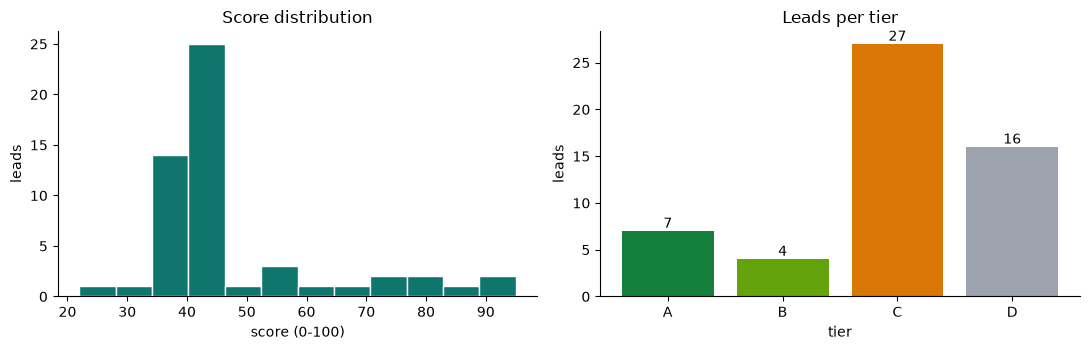

In [5]:
import matplotlib.pyplot as plt

TIER_COLOUR = {"A": "#15803d", "B": "#65a30d", "C": "#d97706", "D": "#9ca3af"}
ACCENT = "#0f766e"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))

df["score"].plot.hist(bins=12, ax=ax1, color=ACCENT, edgecolor="white")
ax1.set_title("Score distribution")
ax1.set_xlabel("score (0-100)")
ax1.set_ylabel("leads")
ax1.spines[["top", "right"]].set_visible(False)

tiers = df["tier"].value_counts().reindex(["A", "B", "C", "D"]).fillna(0)
ax2.bar(tiers.index, tiers.values, color=[TIER_COLOUR[t] for t in tiers.index])
ax2.set_title("Leads per tier")
ax2.set_xlabel("tier")
ax2.set_ylabel("leads")
ax2.spines[["top", "right"]].set_visible(False)
for i, v in enumerate(tiers.values):
    ax2.text(i, v, int(v), ha="center", va="bottom")

plt.tight_layout()
plt.show()


## 5. Re-ranking is client-side arithmetic

Each lead carries its five factor scores as points out of a maximum. The total is just

$$\text{score} = \sum_f \frac{\text{points}_f}{\text{max}_f} \times \text{weight}_f$$

with the weights summing to 100. That means moving a weight slider re-ranks the table in
the browser with no network call, and it means this notebook can reproduce the app's
arithmetic exactly. The `succession` preset triples the succession weight and halves the
digital-gap weight, which promotes long-established owner-operated businesses.

In [6]:
PRESETS = {
    "balanced":   {"reachability": 25, "establishment": 20, "digital_gap": 20, "buybox": 20, "succession": 15},
    "succession": {"reachability": 25, "establishment": 15, "digital_gap": 10, "buybox": 20, "succession": 30},
}

factors = pd.json_normalize(leads, "factor_scores", ["id"])
ratio = (
    factors.assign(ratio=factors["points"] / factors["max_points"])
    .pivot(index="id", columns="factor", values="ratio")
)


def rescore(weights: dict[str, float]) -> pd.Series:
    return sum(ratio[f] * w for f, w in weights.items()).round(1)


names = df.set_index("id")["display_name"]
compare = pd.DataFrame({
    "name": names,
    "balanced": rescore(PRESETS["balanced"]),
    "succession": rescore(PRESETS["succession"]),
})
compare["move"] = (
    compare["succession"].rank(ascending=False).astype(int)
    - compare["balanced"].rank(ascending=False).astype(int)
) * -1

# Sanity check: recomputing the balanced preset must reproduce the server's own score.
delta = (compare["balanced"] - df.set_index("id")["score"]).abs().max()
print(f"max disagreement with the server's stored score: {delta:.2f} points")

print("\nTop 5 under each preset")
top = pd.concat([
    compare.nlargest(5, "balanced")[["name", "balanced"]].reset_index(drop=True),
    compare.nlargest(5, "succession")[["name", "succession"]].reset_index(drop=True),
], axis=1)
top


max disagreement with the server's stored score: 0.00 points

Top 5 under each preset


,name,balanced,name,succession
0,KC Dental,95.0,KC Dental,97.5
1,Dental Smiles Family & Cosmetic Dentistry,92.0,Kunik Orthodontics,92.5
2,Kunik Orthodontics,86.0,Dental Smiles Family & Cosmetic Dentistry,91.5
3,Smile 360,81.0,Smile 360,84.5
4,Canvas Dental,77.0,Canvas Dental,74.0


In [7]:
# Who gains most from caring about succession?
compare.nlargest(8, "move")[["name", "balanced", "succession", "move"]].reset_index(drop=True)


,name,balanced,succession,move
0,"Edwin Webb, DDS",43.0,37.2,11
1,My Care Dental,43.0,37.2,11
2,Smiles by Garcia,43.0,37.2,11
3,Tech Ridge Dental,66.0,65.0,1
4,Kunik Orthodontics,86.0,92.5,1
5,Central Texas Pediatric Dentistry,55.0,49.2,1
6,Lamar Dental Center,36.0,26.0,0
7,Hammons Family Dental,36.0,26.0,0


## 6. Contact quality, which is the part that decides whether a list is usable

A lead nobody can reach is worth nothing, so the pipeline records where each contact came
from and whether it survived verification. Emails get an MX lookup plus a disposable-domain
check; phones go through `phonenumbers`. Nothing here is guessed by a language model:
structured fields are never generated or reformatted by the model, by design.

In [8]:
contacts = pd.json_normalize(leads, "contacts", ["id"])
if contacts.empty:
    print("no contacts found in this run")
else:
    matrix = (
        contacts.groupby(["kind", "source", "verification_status"])
        .size()
        .unstack(fill_value=0)
    )
    display(matrix)

    reach = pd.Series({
        "leads total": len(df),
        "with a website in OSM": int(df["website"].notna().sum()),
        "site crawled ok": int((df["enrichment_status"] == "ok").sum()),
        "with any contact": int(contacts["id"].nunique()),
        "with a verified email": int(
            contacts[(contacts["kind"] == "email") & (contacts["verification_status"] == "verified")]["id"].nunique()
        ),
    })
    display(reach.to_frame("leads"))


verification_status  not_checked  valid  verified
kind   source                                    
email  osm                     0      0         5
       website                 0      0         2
phone  osm                     0     17         0
       website                 0      9         0
social website                26      0         0

,leads
leads total,54
with a website in OSM,18
site crawled ok,12
with any contact,18
with a verified email,7


## 7. What the numbers say

Read these as a description of this one run, not a universal claim.

**Most of these businesses have no website at all.** That is the single most important
number on the page, and in this market it is roughly two thirds of them. For a lead-gen
tool the naive reading is "bad data". For a searcher it is the opposite: a profitable
local business that never built a website is a business whose owner is not optimising for
growth, which is exactly the profile worth a phone call. `digital_gap` is therefore a
*positive* scoring factor, and the ranking would be worse without those leads in it.

**The AI pass touches a minority of leads and that is deliberate.** Extraction only runs
when the regular expressions leave a gap worth filling, so most leads never reach the
model. That keeps the run inside a free tier and keeps the provenance honest: every signal
in the drawer says whether a regex or the model produced it.

**Verified contact coverage is the honest ceiling on this list.** Only the leads with a
reachable site and a real, MX-verified email are ones a searcher can email today; the rest
are a phone call. The `reachability` factor carries the largest weight for that reason.

The extraction accuracy behind those AI-sourced signals is measured separately against a
hand-labelled set in [`../evals/`](../evals/README.md), including the cases where the
model does no better than the regular expressions.

> A section querying the database directly with SQL was planned here and dropped. It would
> have needed SQLAlchemy and a Postgres driver in this environment to show two aggregates
> the API already exposes, against a database a reader of this notebook does not have.